# MVP v0.2.5.11: D4RL SOPE Calibration — Does Guidance Work on Within-Dataset Policies?

**Date:** 2026-03-17
**Builds on:** v0.2.5.10 (action distribution diagnostics)

## Question

v0.2.5.10 showed Lift policies have diversity comparable to D4RL within-dataset (subsets of same data)
but much less than D4RL cross-dataset (random/medium/expert). **Does SOPE guidance actually work
in the within-dataset regime?** If not, this confirms guidance-based OPE fundamentally requires
cross-dataset-level diversity.

## Setup

**Cross-dataset (6 policies):** BC_Gaussian trained on hopper-{random, medium, medium-replay, medium-expert, expert, full-replay}
**Within-dataset (6 policies):** BC_Gaussian trained on {500, 1k, 5k, 10k, 50k, 100k} transitions from hopper-medium-v2

Pipeline per policy set:
1. Train BC_Gaussian policies
2. Roll out in hopper for oracle values (gamma=0.99, horizon=768, 100 rollouts)
3. Custom diagnostics (KL, cosine, W1, classifier)
4. Guided generation using pre-trained hopper diffuser (50 trajectories, T_gen=768)
5. Score with learned reward model
6. Compute SOPE metrics: Spearman, Pearson, Regret@1, Regret@2, logRMSE

In [1]:
%matplotlib inline
import sys, os, math, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import wasserstein_distance, spearmanr, pearsonr

warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["D4RL_SUPPRESS_IMPORT_ERROR"] = "1"

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

import gym
import d4rl
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import apply_conditioning

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Config ──
HOPPER_OBS_DIM = 11
HOPPER_ACT_DIM = 3
GAMMA = 0.99
HORIZON = 768
N_ORACLE_ROLLOUTS = 100
N_SYNTHETIC = 50
CHUNK_SIZE = 8       # T in SOPE config
N_DIFFUSION_STEPS = 256  # D in SOPE config
DIM_MULTS = (1, 2, 4, 8)
BC_HIDDEN = [256, 256]
BC_LR = 1e-4
BC_BATCH = 256
BC_EPOCHS = 100

SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "d4rl_bc_gaussian"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# SOPE guidance hyperparams (from hopper_stitch.json)
GUIDANCE = {
    "action_scale": 0.5,
    "use_adaptive": False,
    "use_neg_grad": True,
    "neg_grad_scale": 0.1,
    "normalize_grad": True,
    "k_guide": 1,
    "use_action_grad_only": True,
    "clamp": True,
    "l_inf": 1,
    "ratio": 0.5,
}

print("Setup complete")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group


<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


pybullet build time: Jan 29 2025 23:16:28


Device: cuda
Setup complete


In [2]:
# ── GaussianPolicy ──
class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims=[256, 256],
                 init_std=0.3, min_std=0.01, max_std=7.5):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.min_std = min_std
        self.max_std = max_std
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_dim, action_dim)
        self.log_std_head = nn.Linear(in_dim, action_dim)
        nn.init.constant_(self.log_std_head.bias, np.log(np.exp(init_std) - 1.0))
        nn.init.zeros_(self.log_std_head.weight)

    def forward(self, obs):
        h = self.backbone(obs)
        mean = self.mean_head(h)
        std = torch.clamp(F.softplus(self.log_std_head(h)), min=self.min_std, max=self.max_std)
        return mean, std

    def log_prob(self, obs, action):
        mean, std = self.forward(obs)
        return torch.distributions.Normal(mean, std).log_prob(action).sum(-1)

    @torch.no_grad()
    def grad_log_prob(self, obs, action):
        """Interface matches SOPE's gradlog_diffusion: (N*T, D) -> (N*T, act_dim)"""
        mean, std = self.forward(obs)
        return -(action - mean) / (std ** 2)

    @torch.no_grad()
    def sample_actions(self, obs):
        mean, std = self.forward(obs)
        return mean + std * torch.randn_like(mean)

    def sample(self, obs_np):
        """For oracle rollouts — numpy in/out."""
        obs_t = torch.tensor(obs_np, dtype=torch.float32, device=next(self.parameters()).device).unsqueeze(0)
        act = self.sample_actions(obs_t)
        return act.squeeze(0).cpu().numpy()

    def train_on_data(self, obs, actions, n_epochs, batch_size=256, lr=1e-4):
        opt = torch.optim.Adam(self.parameters(), lr=lr)
        dev = next(self.parameters()).device
        obs_t = torch.tensor(obs, dtype=torch.float32, device=dev)
        act_t = torch.tensor(actions, dtype=torch.float32, device=dev)
        N = len(obs_t)
        steps_per_epoch = max(1, N // batch_size)
        self.train()
        for epoch in range(n_epochs):
            perm = torch.randperm(N, device=dev)
            for step in range(steps_per_epoch):
                idx = perm[step * batch_size:(step + 1) * batch_size]
                if len(idx) == 0: continue
                nll = -self.log_prob(obs_t[idx], act_t[idx]).mean()
                opt.zero_grad(); nll.backward(); opt.step()
        self.eval()
        final_nll = -self.log_prob(obs_t[:1000], act_t[:1000]).mean().item()
        return final_nll

print("GaussianPolicy defined")

GaussianPolicy defined


In [3]:
# ── Step 1: Load D4RL data + Train 12 BC_Gaussian policies + Save weights ──
CROSS_ENVS = [
    "hopper-random-v2", "hopper-medium-v2", "hopper-medium-replay-v2",
    "hopper-medium-expert-v2", "hopper-expert-v2", "hopper-full-replay-v2",
]
WITHIN_SIZES = [500, 1000, 5000, 10000, 50000, 100000]

# Load cross-dataset data
cross_data = {}
print("Loading cross-dataset D4RL data...")
for env_name in CROSS_ENVS:
    env = gym.make(env_name)
    dataset = d4rl.qlearning_dataset(env)
    short = env_name.replace("hopper-", "").replace("-v2", "")
    cross_data[short] = {
        "obs": dataset["observations"].astype(np.float32),
        "actions": dataset["actions"].astype(np.float32),
    }
    print(f"  {short:<20} {len(cross_data[short]['obs']):>8} transitions")
    env.close()

# Load within-dataset data (subsets of medium)
within_data = {}
rng = np.random.RandomState(42)
medium_obs = cross_data["medium"]["obs"]
medium_act = cross_data["medium"]["actions"]
print("\nWithin-dataset subsets of medium:")
for size in WITHIN_SIZES:
    name = f"med_{size//1000}k" if size >= 1000 else f"med_{size}"
    idx = rng.permutation(len(medium_obs))[:size]
    within_data[name] = {"obs": medium_obs[idx], "actions": medium_act[idx]}
    print(f"  {name:<20} {size:>8} transitions")

cross_names = list(cross_data.keys())
within_names = list(within_data.keys())

# Train policies
all_policies = {}
print(f"\n{'='*60}")
print("Training cross-dataset BC_Gaussian policies...")
for name in cross_names:
    data = cross_data[name]
    print(f"  {name:<20}", end=" ", flush=True)
    t0 = time.time()
    pol = GaussianPolicy(HOPPER_OBS_DIM, HOPPER_ACT_DIM, hidden_dims=BC_HIDDEN).to(device)
    nll = pol.train_on_data(data["obs"], data["actions"], n_epochs=BC_EPOCHS, batch_size=BC_BATCH, lr=BC_LR)
    all_policies[name] = pol
    elapsed = time.time() - t0
    print(f"NLL={nll:.3f}, {elapsed:.0f}s")
    # Save weights
    torch.save({"state_dict": pol.state_dict(), "obs_dim": HOPPER_OBS_DIM, "act_dim": HOPPER_ACT_DIM,
                "hidden_dims": BC_HIDDEN, "name": name, "nll": nll},
               SAVE_DIR / f"cross_{name}.pt")

print("\nTraining within-dataset BC_Gaussian policies...")
for name in within_names:
    data = within_data[name]
    print(f"  {name:<20}", end=" ", flush=True)
    t0 = time.time()
    pol = GaussianPolicy(HOPPER_OBS_DIM, HOPPER_ACT_DIM, hidden_dims=BC_HIDDEN).to(device)
    nll = pol.train_on_data(data["obs"], data["actions"], n_epochs=BC_EPOCHS, batch_size=BC_BATCH, lr=BC_LR)
    all_policies[name] = pol
    elapsed = time.time() - t0
    print(f"NLL={nll:.3f}, {elapsed:.0f}s")
    torch.save({"state_dict": pol.state_dict(), "obs_dim": HOPPER_OBS_DIM, "act_dim": HOPPER_ACT_DIM,
                "hidden_dims": BC_HIDDEN, "name": name, "nll": nll},
               SAVE_DIR / f"within_{name}.pt")

print(f"\nSaved all weights to {SAVE_DIR}")
print(f"Total policies: {len(all_policies)}")

/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loading cross-dataset D4RL data...


load datafile:   0%|          | 0/9 [00:00<?, ?it/s]

load datafile:  11%|█         | 1/9 [00:00<00:00,  8.36it/s]

load datafile:  33%|███▎      | 3/9 [00:00<00:00,  6.65it/s]

...

NLL=1.658, 3s
  med_5k               

NLL=0.534, 17s
  med_10k              

NLL=0.423, 35s
  med_50k              

NLL=-0.224, 174s
  med_100k             

NLL=-0.476, 348s

Saved all weights to /home1/reishuen/latent_sope/diffusion_ckpts/d4rl_bc_gaussian
Total policies: 12


In [4]:
# ── Step 2: Oracle rollouts in hopper ──
def oracle_value(policy, env_name, n_rollouts, horizon, gamma):
    """Roll out policy in env, return discounted returns."""
    returns = []
    env = gym.make(env_name)
    for i in range(n_rollouts):
        obs = env.reset()
        total = 0.0
        gamma_t = 1.0
        for t in range(horizon):
            action = policy.sample(obs)
            action = np.clip(action, env.action_space.low, env.action_space.high)
            obs, reward, done, info = env.step(action)
            total += gamma_t * reward
            gamma_t *= gamma
            if done:
                break
        returns.append(total)
    env.close()
    return np.array(returns)

print(f"{'='*60}")
print(f"Step 2: Oracle rollouts (n={N_ORACLE_ROLLOUTS}, horizon={HORIZON}, gamma={GAMMA})")
print(f"{'='*60}\n")

oracle_values = {}
t0_all = time.time()
for name, pol in all_policies.items():
    t0 = time.time()
    rets = oracle_value(pol, "hopper-medium-v2", N_ORACLE_ROLLOUTS, HORIZON, GAMMA)
    oracle_values[name] = {"mean": rets.mean(), "std": rets.std(), "returns": rets}
    group = "CROSS" if name in cross_names else "WITHIN"
    print(f"  [{group}] {name:<20} V={rets.mean():.1f} +/- {rets.std():.1f}, {time.time()-t0:.0f}s")

print(f"\nTotal oracle time: {time.time()-t0_all:.0f}s")

# Summary
print(f"\nCross-dataset oracle values:")
for n in cross_names:
    print(f"  {n:<20} {oracle_values[n]['mean']:>8.1f}")
print(f"\nWithin-dataset oracle values:")
for n in within_names:
    print(f"  {n:<20} {oracle_values[n]['mean']:>8.1f}")

Step 2: Oracle rollouts (n=100, horizon=768, gamma=0.99)



  [CROSS] random               V=17.8 +/- 13.7, 1s


  [CROSS] medium               V=213.1 +/- 16.2, 24s


  [CROSS] medium-replay        V=159.9 +/- 42.7, 14s


  [CROSS] medium-expert        V=224.8 +/- 21.3, 25s


...

  [WITHIN] med_1k               V=142.0 +/- 32.1, 7s


  [WITHIN] med_5k               V=195.3 +/- 28.1, 16s


  [WITHIN] med_10k              V=209.7 +/- 15.3, 18s


  [WITHIN] med_50k              V=207.1 +/- 20.9, 22s


  [WITHIN] med_100k             V=217.1 +/- 16.6, 24s

Total oracle time: 196s

Cross-dataset oracle values:
  random                   17.8
  medium                  213.1
  medium-replay           159.9
  medium-expert           224.8
  expert                  257.5
  full-replay             218.3

Within-dataset oracle values:
  med_500                  72.4
  med_1k                  142.0
  med_5k                  195.3
  med_10k                 209.7
  med_50k                 207.1
  med_100k                217.1


In [5]:
# ── Step 3: Custom diagnostics (KL, cosine, W1, classifier) ──
@torch.no_grad()
def pairwise_kl(pol_i, pol_j, obs_t):
    mu_i, std_i = pol_i(obs_t)
    mu_j, std_j = pol_j(obs_t)
    kl = (torch.log(std_j / std_i) + (std_i**2 + (mu_i - mu_j)**2) / (2 * std_j**2) - 0.5).sum(-1)
    return kl.cpu().numpy()

def compute_diagnostics(policy_names, policies, test_obs, act_dim, label):
    """Compute KL, cosine, W1, classifier for a set of policies."""
    n = len(policy_names)
    test_act = policies[policy_names[0]].sample_actions(test_obs).cpu()
    
    # Cosine + KL
    grads = {nm: policies[nm].grad_log_prob(test_obs, torch.tensor(
        policies[policy_names[0]].sample_actions(test_obs).cpu().numpy(),
        dtype=torch.float32, device=device)).cpu() for nm in policy_names}
    
    kl_off, cos_off, w1_off = [], [], []
    for i in range(n):
        for j in range(i+1, n):
            kl_vals = pairwise_kl(policies[policy_names[i]], policies[policy_names[j]], test_obs)
            kl_off.append(kl_vals.mean())
            cos = F.cosine_similarity(grads[policy_names[i]], grads[policy_names[j]], dim=-1).mean().item()
            cos_off.append(cos)
            # W1
            a_i = policies[policy_names[i]].sample_actions(test_obs).cpu().numpy()
            a_j = policies[policy_names[j]].sample_actions(test_obs).cpu().numpy()
            w1_dims = [wasserstein_distance(a_i[:, d], a_j[:, d]) for d in range(act_dim)]
            w1_off.append(np.mean(w1_dims))
    
    # Classifier
    n_samp = min(500, test_obs.shape[0])
    all_sa, all_labels = [], []
    for idx, nm in enumerate(policy_names):
        acts = policies[nm].sample_actions(test_obs[:n_samp]).cpu()
        sa = torch.cat([test_obs[:n_samp].cpu(), acts], -1)
        all_sa.append(sa)
        all_labels.append(torch.full((n_samp,), idx, dtype=torch.long))
    all_sa = torch.cat(all_sa); all_labels = torch.cat(all_labels)
    N = len(all_sa); perm = torch.randperm(N); n_train = int(0.8 * N)
    tr_sa, tr_y = all_sa[perm[:n_train]].to(device), all_labels[perm[:n_train]].to(device)
    te_sa, te_y = all_sa[perm[n_train:]].to(device), all_labels[perm[n_train:]].to(device)
    clf = nn.Sequential(nn.Linear(test_obs.shape[1]+act_dim, 128), nn.ReLU(),
                         nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, n)).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    for ep in range(200):
        clf.train(); idx = torch.randperm(n_train, device=device)
        for s in range(0, n_train, 256):
            bi = idx[s:s+256]; loss = F.cross_entropy(clf(tr_sa[bi]), tr_y[bi])
            opt.zero_grad(); loss.backward(); opt.step()
    clf.eval()
    with torch.no_grad():
        acc = (clf(te_sa).argmax(-1) == te_y).float().mean().item()
    
    result = {
        "mean_kl": np.mean(kl_off), "mean_cos": np.mean(cos_off),
        "mean_w1": np.mean(w1_off), "classifier_acc": acc, "chance": 1.0/n,
    }
    print(f"\n{label}:")
    print(f"  KL={result['mean_kl']:.2f}, Cos={result['mean_cos']:.4f}, "
          f"W1={result['mean_w1']:.4f}, Clf={acc:.1%} (chance={1/n:.1%})")
    return result

# Test observations from medium dataset
test_obs_t = torch.tensor(cross_data["medium"]["obs"][:500], dtype=torch.float32, device=device)

print(f"{'='*60}")
print("Step 3: Custom Diagnostics")
print(f"{'='*60}")

cross_diag = compute_diagnostics(cross_names, all_policies, test_obs_t, HOPPER_ACT_DIM, "Cross-dataset (6 policies)")
within_diag = compute_diagnostics(within_names, all_policies, test_obs_t, HOPPER_ACT_DIM, "Within-dataset (6 policies)")

Step 3: Custom Diagnostics



Cross-dataset (6 policies):
  KL=126.30, Cos=0.2520, W1=0.1452, Clf=31.2% (chance=16.7%)



Within-dataset (6 policies):
  KL=17.80, Cos=0.1452, W1=0.0794, Clf=15.3% (chance=16.7%)


In [6]:
# ── Step 3b: Additional diagnostics (from hopper_d4rl_diagnostics.md reference) ──
# These match the diagnostics run on SOPE's original 11 SAC policies for Hopper.
# Reference values: mean cosine=0.4737, |grad|/|act|=572.7, NLL spread 3.9-43.8

test_act_t = torch.tensor(cross_data["medium"]["actions"][:500], dtype=torch.float32, device=device)

def compute_extra_diagnostics(policy_names, policies, test_obs, test_act, act_dim, label):
    """Compute |grad|/|action| ratio, GD convergence, Action NLL."""
    n = len(policy_names)
    
    # ── |grad|/|action| ratio ──
    print(f"\n  |grad|/|action| ratio:")
    grad_ratios = {}
    for nm in policy_names:
        g = policies[nm].grad_log_prob(test_obs, test_act)
        grad_norm = g.norm(dim=-1).mean().item()
        act_norm = test_act.norm(dim=-1).mean().item()
        ratio = grad_norm / max(act_norm, 1e-6)
        grad_ratios[nm] = {"grad_norm": grad_norm, "ratio": ratio}
        print(f"    {nm:<20} |grad|={grad_norm:.1f}, |act|={act_norm:.2f}, ratio={ratio:.1f}")
    mean_ratio = np.mean([v["ratio"] for v in grad_ratios.values()])
    print(f"    Mean ratio: {mean_ratio:.1f} (Hopper SAC ref: 572.7)")
    
    # ── Gradient direction test (GD convergence) ──
    print(f"\n  Gradient direction test (lr=0.1, 50 steps, 200 samples):")
    gd_results = {}
    for nm in policy_names:
        pol = policies[nm]
        n_samp = min(200, test_obs.shape[0])
        obs_batch = test_obs[:n_samp]
        real_act = test_act[:n_samp]
        # Start from random actions
        rand_act = torch.randn_like(real_act)
        init_dist = (rand_act - real_act).norm(dim=-1).mean().item()
        # Gradient ascent with action clamping to prevent NaN
        cur_act = rand_act.clone().detach().requires_grad_(True)
        for step in range(50):
            log_p = pol.log_prob(obs_batch, cur_act)
            if torch.isnan(log_p).any():
                print(f"    {nm}: NaN in log_prob at step {step}, stopping early")
                break
            log_p.sum().backward()
            with torch.no_grad():
                cur_act.data += 0.1 * cur_act.grad
                cur_act.data.clamp_(-10, 10)  # prevent action explosion
            cur_act.grad.zero_()
        final_dist = (cur_act.detach() - real_act).norm(dim=-1).mean().item()
        improvement = (final_dist - init_dist) / init_dist * 100
        gd_results[nm] = improvement
        print(f"    {nm:<20} init={init_dist:.3f} final={final_dist:.3f} Δ={improvement:+.1f}%")
    mean_gd = np.mean(list(gd_results.values()))
    print(f"    Mean improvement: {mean_gd:+.1f}% (Hopper SAC ref: -26.3%)")
    
    # ── Action NLL under target policies ──
    print(f"\n  Action NLL (synthetic actions evaluated under each policy):")
    # Use actions sampled from the first policy as "synthetic" baseline
    synth_act = policies[policy_names[0]].sample_actions(test_obs).detach()
    nll_results = {}
    for nm in policy_names:
        nll = -policies[nm].log_prob(test_obs, synth_act).mean().item()
        nll_results[nm] = nll
        print(f"    {nm:<20} NLL={nll:.2f}")
    nll_vals = list(nll_results.values())
    nll_spread = max(nll_vals) - min(nll_vals)
    print(f"    NLL range: [{min(nll_vals):.1f}, {max(nll_vals):.1f}] (spread={nll_spread:.1f})")
    print(f"    (Hopper SAC ref: spread=39.9, range [3.9, 43.8])")
    
    return {"grad_ratios": grad_ratios, "mean_ratio": mean_ratio,
            "gd_results": gd_results, "mean_gd": mean_gd,
            "nll_results": nll_results, "nll_spread": nll_spread}

print(f"{'='*60}")
print("Step 3b: Additional Diagnostics (matching hopper_d4rl_diagnostics.md)")
print(f"{'='*60}")

cross_extra = compute_extra_diagnostics(cross_names, all_policies, test_obs_t, test_act_t,
                                         HOPPER_ACT_DIM, "Cross-dataset")
within_extra = compute_extra_diagnostics(within_names, all_policies, test_obs_t, test_act_t,
                                          HOPPER_ACT_DIM, "Within-dataset")

# Comparison table
print(f"\n{'='*60}")
print(f"{'Metric':<25} {'Cross':>10} {'Within':>10} {'SAC ref':>10}")
print(f"{'─'*55}")
print(f"{'|grad|/|act| ratio':<25} {cross_extra['mean_ratio']:>10.1f} {within_extra['mean_ratio']:>10.1f} {'572.7':>10}")
print(f"{'GD convergence':<25} {cross_extra['mean_gd']:>+9.1f}% {within_extra['mean_gd']:>+9.1f}% {'-26.3%':>10}")
print(f"{'NLL spread':<25} {cross_extra['nll_spread']:>10.1f} {within_extra['nll_spread']:>10.1f} {'39.9':>10}")

Step 3b: Additional Diagnostics (matching hopper_d4rl_diagnostics.md)

  |grad|/|action| ratio:
    random               |grad|=3.4, |act|=1.08, ratio=3.1
    medium               |grad|=13.4, |act|=1.08, ratio=12.4
    medium-replay        |grad|=10.0, |act|=1.08, ratio=9.3
    medium-expert        |grad|=12.5, |act|=1.08, ratio=11.6
    expert               |grad|=105.0, |act|=1.08, ratio=97.0
    full-replay          |grad|=8.2, |act|=1.08, ratio=7.5
    Mean ratio: 23.5 (Hopper SAC ref: 572.7)

  Gradient direction test (lr=0.1, 50 steps, 200 samples):


    random               init=1.919 final=1.093 Δ=-43.1%


    medium               init=1.912 final=11.579 Δ=+505.5%


    medium-replay        init=1.847 final=4.402 Δ=+138.3%


    medium-expert        init=1.926 final=11.320 Δ=+487.8%


...

    med_1k               init=1.956 final=0.800 Δ=-59.1%


    med_5k               init=1.820 final=4.102 Δ=+125.4%


    med_10k              init=1.845 final=5.150 Δ=+179.1%


    med_50k              init=1.932 final=8.897 Δ=+360.6%


    med_100k             init=1.827 final=10.066 Δ=+450.9%
    Mean improvement: +167.2% (Hopper SAC ref: -26.3%)

  Action NLL (synthetic actions evaluated under each policy):
    med_500              NLL=1.63
    med_1k               NLL=1.95
    med_5k               NLL=6.75
    med_10k              NLL=15.96
    med_50k              NLL=57.91
    med_100k             NLL=76.10
    NLL range: [1.6, 76.1] (spread=74.5)
    (Hopper SAC ref: spread=39.9, range [3.9, 43.8])

Metric                         Cross     Within    SAC ref
───────────────────────────────────────────────────────
|grad|/|act| ratio              23.5        6.5      572.7
GD convergence               +288.7%    +167.2%     -26.3%
NLL spread                     562.9       74.5       39.9


In [7]:
# ── Step 4: Load pre-trained hopper diffuser + normalization ──
print("Loading pre-trained hopper diffuser...")

# Normalization from hopper-medium-v2 (same as SOPE)
env_norm = gym.make("hopper-medium-v2")
dataset_norm = env_norm.get_dataset()
obs_all = dataset_norm["observations"].astype(np.float32)
act_all = dataset_norm["actions"].astype(np.float32)
norm_mean = np.concatenate([obs_all.mean(0), act_all.mean(0)])
norm_std = np.concatenate([obs_all.std(0), act_all.std(0)])
norm_mean_t = torch.tensor(norm_mean, dtype=torch.float32, device=device)
norm_std_t = torch.tensor(norm_std, dtype=torch.float32, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t
env_norm.close()

# Load model
TRANSITION_DIM = HOPPER_OBS_DIM + HOPPER_ACT_DIM  # 14
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim_mults=DIM_MULTS, attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=HOPPER_OBS_DIM, action_dim=HOPPER_ACT_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=True, loss_type="l2",
    clip_denoised=False, action_weight=5.0,
).to(device)

model_path = PROJECT_ROOT / "third_party/sope/opelab/examples/d4rl/models/hopper.pth"
diffusion_model.load_state_dict(torch.load(model_path, map_location=device))
diffusion_model.eval()
print(f"Loaded diffuser from {model_path}")

# Hopper termination function (from SOPE)
def hopper_terminated(state):
    state_np = state.cpu().numpy() if isinstance(state, torch.Tensor) else state
    height = state_np[0]
    ang = state_np[1]
    return not (np.isfinite(state_np).all() and (np.abs(state_np[2:]) < 100).all()
                and (height > 0.7) and (abs(ang) < 0.2))

print("Diffuser ready")

Loading pre-trained hopper diffuser...


load datafile:   0%|          | 0/21 [00:00<?, ?it/s]

load datafile:  10%|▉         | 2/21 [00:00<00:01, 17.56it/s]

load datafile:  19%|█▉        | 4/21 [00:00<00:03,  5.26it/s]

load datafile:  81%|████████  | 17/21 [00:00<00:00, 20.25it/s]

load datafile:  95%|█████████▌| 20/21 [00:01<00:00, 15.92it/s]

load datafile: 100%|██████████| 21/21 [00:01<00:00, 15.86it/s]

[ models/temporal ] Channel dimensions: [(14, 32), (32, 64), (64, 128), (128, 256)]
[(14, 32), (32, 64), (64, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded diffuser from /home1/reishuen/latent_sope/third_party/sope/opelab/examples/d4rl/models/hopper.pth
Diffuser ready


In [8]:
# ── Step 5: Train reward model (JAX-based, from SOPE) ──
from opelab.core.data import Data

print("Training reward model on hopper-medium-v2...")
env_rm = gym.make("hopper-medium-v2")
data_helper = Data(env_rm)
offline_data = data_helper.load_d4rl_dataset()
reward_estimator = data_helper.train_reward_estimator(offline_data)
env_rm.close()
print("Reward model ready")

/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Training reward model on hopper-medium-v2...
Loading D4RL dataset...


load datafile:   0%|          | 0/21 [00:00<?, ?it/s]

load datafile:  10%|▉         | 2/21 [00:00<00:01, 18.98it/s]

load datafile:  19%|█▉        | 4/21 [00:00<00:03,  5.37it/s]

...

Loaded 2186 episodes from D4RL dataset.
Training the reward Estimator


iter 0 mse 14.29703140258789
iter 50 mse 2.6457207202911377
iter 100 mse 0.21642965078353882
iter 150 mse 0.08621780574321747


iter 200 mse 0.05038963630795479
iter 250 mse 0.03738659247756004
iter 300 mse 0.02692495845258236
iter 350 mse 0.01829988695681095
iter 400 mse 0.016894619911909103
iter 450 mse 0.01352978590875864
iter 500 mse 0.011892054229974747
iter 550 mse 0.011350118555128574


iter 600 mse 0.01002164464443922
iter 650 mse 0.010563340038061142
iter 700 mse 0.008096826262772083
iter 750 mse 0.007329494692385197
iter 800 mse 0.007897516712546349
iter 850 mse 0.006848221179097891
iter 900 mse 0.005876284092664719
iter 950 mse 0.0055745732970535755


Reward model ready


In [9]:
# ── Step 6: Guided generation + scoring ──
from opelab.core.baselines.diffusion.diffusion import gradlog_diffusion

def generate_guided_trajectories(dm, target_policy, normalize_fn, unnormalize_fn,
                                  state_dim, action_dim, chunk_size, t_gen,
                                  n_samples, device, guidance_params, terminate_fn=None):
    """Generate guided trajectories using SOPE's diffusion model."""
    B = n_samples
    td = state_dim + action_dim
    
    # Get initial states from hopper env resets
    env = gym.make("hopper-medium-v2")
    init_states = np.zeros((B, state_dim), dtype=np.float32)
    for i in range(B):
        init_states[i] = env.reset()
    env.close()
    init_t = torch.tensor(init_states, dtype=torch.float32, device=device)
    
    pad = torch.cat([init_t, torch.zeros(B, action_dim, device=device)], 1)
    cond = {0: normalize_fn(pad)[:, :state_dim]}
    all_traj = torch.zeros(B, t_gen, td, device=device)
    end_indices = torch.full((B,), t_gen, dtype=torch.long, device=device)
    alive = torch.arange(B, device=device)
    total = 0
    
    action_scale = guidance_params["action_scale"]
    normalize_grad = guidance_params["normalize_grad"]
    
    while alive.numel() > 0 and total < t_gen:
        cur_B = alive.size(0)
        x = torch.randn(cur_B, chunk_size, td, device=device)
        x = apply_conditioning(x, cond, state_dim)
        
        # Set policy on diffusion model for gradlog_diffusion
        dm.policy = target_policy
        
        for t_d in reversed(range(dm.n_timesteps)):
            t_t = torch.full((cur_B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = dm.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)
            
            # Guidance: use gradlog_diffusion (matches SOPE exactly)
            mm_u = unnormalize_fn(mm)
            grad = gradlog_diffusion(target_policy, mm_u, state_dim, action_dim,
                                      normalize=normalize_grad)
            grad = grad.to(device)
            # Apply guidance in unnormalized space
            mm_u[:, :, state_dim:] = mm_u[:, :, state_dim:] + action_scale * grad[:, :, state_dim:]
            mm = normalize_fn(mm_u)
            mm = apply_conditioning(mm, cond, state_dim)
            
            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, cond, state_dim)
        
        chunk_u = unnormalize_fn(x)
        steps = min(chunk_size - 1, t_gen - total)
        
        # Check termination and store
        new_alive = []
        new_local = []
        for local_idx, global_idx in enumerate(alive):
            terminated = False
            for s in range(steps):
                state = chunk_u[local_idx, s, :state_dim]
                if terminate_fn is not None and terminate_fn(state):
                    end_indices[global_idx] = total + s
                    all_traj[global_idx, total:total+s] = chunk_u[local_idx, :s]
                    terminated = True
                    break
            if not terminated:
                all_traj[global_idx, total:total+steps] = chunk_u[local_idx, :steps]
                new_alive.append(global_idx)
                new_local.append(local_idx)
        
        alive = torch.tensor(new_alive, device=device) if new_alive else torch.tensor([], dtype=torch.long, device=device)
        
        if alive.numel() > 0:
            active = x[new_local]
            last = active[:, -1, :state_dim]
            pad = torch.cat([last, torch.zeros(len(new_local), action_dim, device=device)], 1)
            cond = {0: normalize_fn(pad)[:, :state_dim]}
        
        total += steps
    
    return all_traj.detach().cpu().numpy(), end_indices.cpu().numpy()

def score_trajectories(trajs, end_indices, reward_est, state_dim, gamma):
    """Score synthetic trajectories with learned reward model."""
    B = trajs.shape[0]
    returns = []
    for i in range(B):
        T_i = end_indices[i]
        total = 0.0
        gamma_t = 1.0
        for t in range(T_i):
            sa = np.concatenate([trajs[i, t, :state_dim], trajs[i, t, state_dim:]]).reshape(1, -1)
            r = reward_est.predict(sa).mean()
            total += gamma_t * float(r)
            gamma_t *= gamma
        returns.append(total)
    return np.array(returns)

print("Generation + scoring functions defined")

Generation + scoring functions defined


In [10]:
# ── Step 6b: Run guided generation + scoring for all 12 policies ──
# Also generate unguided baseline
print(f"{'='*60}")
print(f"Step 6: Guided generation (n={N_SYNTHETIC}, T_gen={HORIZON})")
print(f"{'='*60}\n")

ope_results = {}  # name -> {"ope_mean", "ope_std", "returns"}

all_names = cross_names + within_names
for i, name in enumerate(all_names):
    pol = all_policies[name]
    group = "CROSS" if name in cross_names else "WITHIN"
    print(f"[{i+1}/{len(all_names)}] [{group}] {name:<20}", end=" ", flush=True)
    
    np.random.seed(42); torch.manual_seed(42)
    t0 = time.time()
    
    trajs, end_idx = generate_guided_trajectories(
        diffusion_model, pol, normalize_fn, unnormalize_fn,
        HOPPER_OBS_DIM, HOPPER_ACT_DIM, CHUNK_SIZE, HORIZON,
        N_SYNTHETIC, device, GUIDANCE, terminate_fn=hopper_terminated,
    )
    gen_time = time.time() - t0
    
    # Score
    returns = score_trajectories(trajs, end_idx, reward_estimator, HOPPER_OBS_DIM, GAMMA)
    ope_results[name] = {
        "ope_mean": returns.mean(), "ope_std": returns.std(), "returns": returns,
        "mean_end_idx": end_idx.mean(),
    }
    
    print(f"OPE={returns.mean():.1f}+/-{returns.std():.1f}, "
          f"avg_len={end_idx.mean():.0f}, {gen_time:.0f}s")

print(f"\nDone.")

Step 6: Guided generation (n=50, T_gen=768)

[1/12] [CROSS] random               

OPE=6.1+/-0.2, avg_len=7, 5s
[2/12] [CROSS] medium               

OPE=6.7+/-0.2, avg_len=7, 4s
[3/12] [CROSS] medium-replay        

OPE=6.6+/-0.2, avg_len=7, 4s
[4/12] [CROSS] medium-expert        

OPE=6.6+/-0.2, avg_len=7, 4s
[5/12] [CROSS] expert               

...

OPE=6.8+/-0.2, avg_len=7, 4s
[9/12] [WITHIN] med_5k               

OPE=6.7+/-0.2, avg_len=7, 4s
[10/12] [WITHIN] med_10k              

OPE=6.8+/-0.1, avg_len=7, 4s
[11/12] [WITHIN] med_50k              

OPE=6.8+/-0.1, avg_len=7, 4s
[12/12] [WITHIN] med_100k             

OPE=6.7+/-0.2, avg_len=7, 4s

Done.


In [11]:
# ── Step 7: Compute SOPE metrics ──
def compute_ope_metrics(policy_names, oracle_vals, ope_results, label, top_k=2):
    """Compute Spearman, Pearson, Regret@1, Regret@k, logRMSE (SOPE-style)."""
    oracle = np.array([oracle_vals[n]["mean"] for n in policy_names])
    ope_est = np.array([ope_results[n]["ope_mean"] for n in policy_names])
    
    # Normalize (SOPE style: min-max normalization)
    V_min, V_max = oracle.min(), oracle.max()
    if V_max - V_min < 1e-6:
        norm_oracle = np.zeros_like(oracle)
        norm_ope = np.zeros_like(ope_est)
    else:
        norm_oracle = (oracle - V_min) / (V_max - V_min)
        norm_ope = (ope_est - V_min) / (V_max - V_min)
    
    # MSE on normalized values
    mse = np.mean((norm_ope - norm_oracle) ** 2)
    log_rmse = np.log(np.sqrt(mse)) if mse > 0 else float("-inf")
    
    # Correlations
    spearman_rho, spearman_p = spearmanr(oracle, ope_est)
    pearson_r, pearson_p = pearsonr(oracle, ope_est)
    
    # Regret@k: best oracle value among top-k by OPE estimate
    top_k_idx = np.argsort(-norm_ope)[:top_k]
    regret_k = norm_oracle.max() - norm_oracle[top_k_idx].max()
    
    # Regret@1
    top_1_idx = np.argsort(-norm_ope)[:1]
    regret_1 = norm_oracle.max() - norm_oracle[top_1_idx].max()
    
    result = {
        "spearman": spearman_rho, "spearman_p": spearman_p,
        "pearson": pearson_r, "pearson_p": pearson_p,
        "regret_1": regret_1, f"regret_{top_k}": regret_k,
        "log_rmse": log_rmse, "mse": mse,
        "oracle": oracle, "ope_est": ope_est,
        "norm_oracle": norm_oracle, "norm_ope": norm_ope,
    }
    
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"\n{'Policy':<22} {'Oracle':>10} {'OPE':>10} {'Norm_Orac':>10} {'Norm_OPE':>10}")
    print("-" * 65)
    for i, n in enumerate(policy_names):
        print(f"{n:<22} {oracle[i]:>10.1f} {ope_est[i]:>10.1f} "
              f"{norm_oracle[i]:>10.3f} {norm_ope[i]:>10.3f}")
    
    print(f"\n  Spearman rho:   {spearman_rho:+.4f} (p={spearman_p:.4f})")
    print(f"  Pearson r:      {pearson_r:+.4f} (p={pearson_p:.4f})")
    print(f"  Regret@1:       {regret_1:.4f}")
    print(f"  Regret@{top_k}:       {regret_k:.4f}")
    print(f"  logRMSE:        {log_rmse:.4f}")
    print(f"  MSE (norm):     {mse:.4f}")
    
    return result

cross_metrics = compute_ope_metrics(cross_names, oracle_values, ope_results,
                                     "CROSS-DATASET (6 policies)", top_k=2)
within_metrics = compute_ope_metrics(within_names, oracle_values, ope_results,
                                      "WITHIN-DATASET (6 policies)", top_k=2)


CROSS-DATASET (6 policies)

Policy                     Oracle        OPE  Norm_Orac   Norm_OPE
-----------------------------------------------------------------
random                       17.8        6.1      0.000     -0.049
medium                      213.1        6.7      0.815     -0.046
medium-replay               159.9        6.6      0.593     -0.047
medium-expert               224.8        6.6      0.864     -0.047
expert                      257.5        7.2      1.000     -0.044
full-replay                 218.3        6.7      0.836     -0.046

  Spearman rho:   +0.6571 (p=0.1562)
  Pearson r:      +0.8829 (p=0.0198)
  Regret@1:       0.0000
  Regret@2:       0.0000
  logRMSE:        -0.2217
  MSE (norm):     0.6419

WITHIN-DATASET (6 policies)

Policy                     Oracle        OPE  Norm_Orac   Norm_OPE
-----------------------------------------------------------------
med_500                      72.4        6.5      0.000     -0.456
med_1k                      14

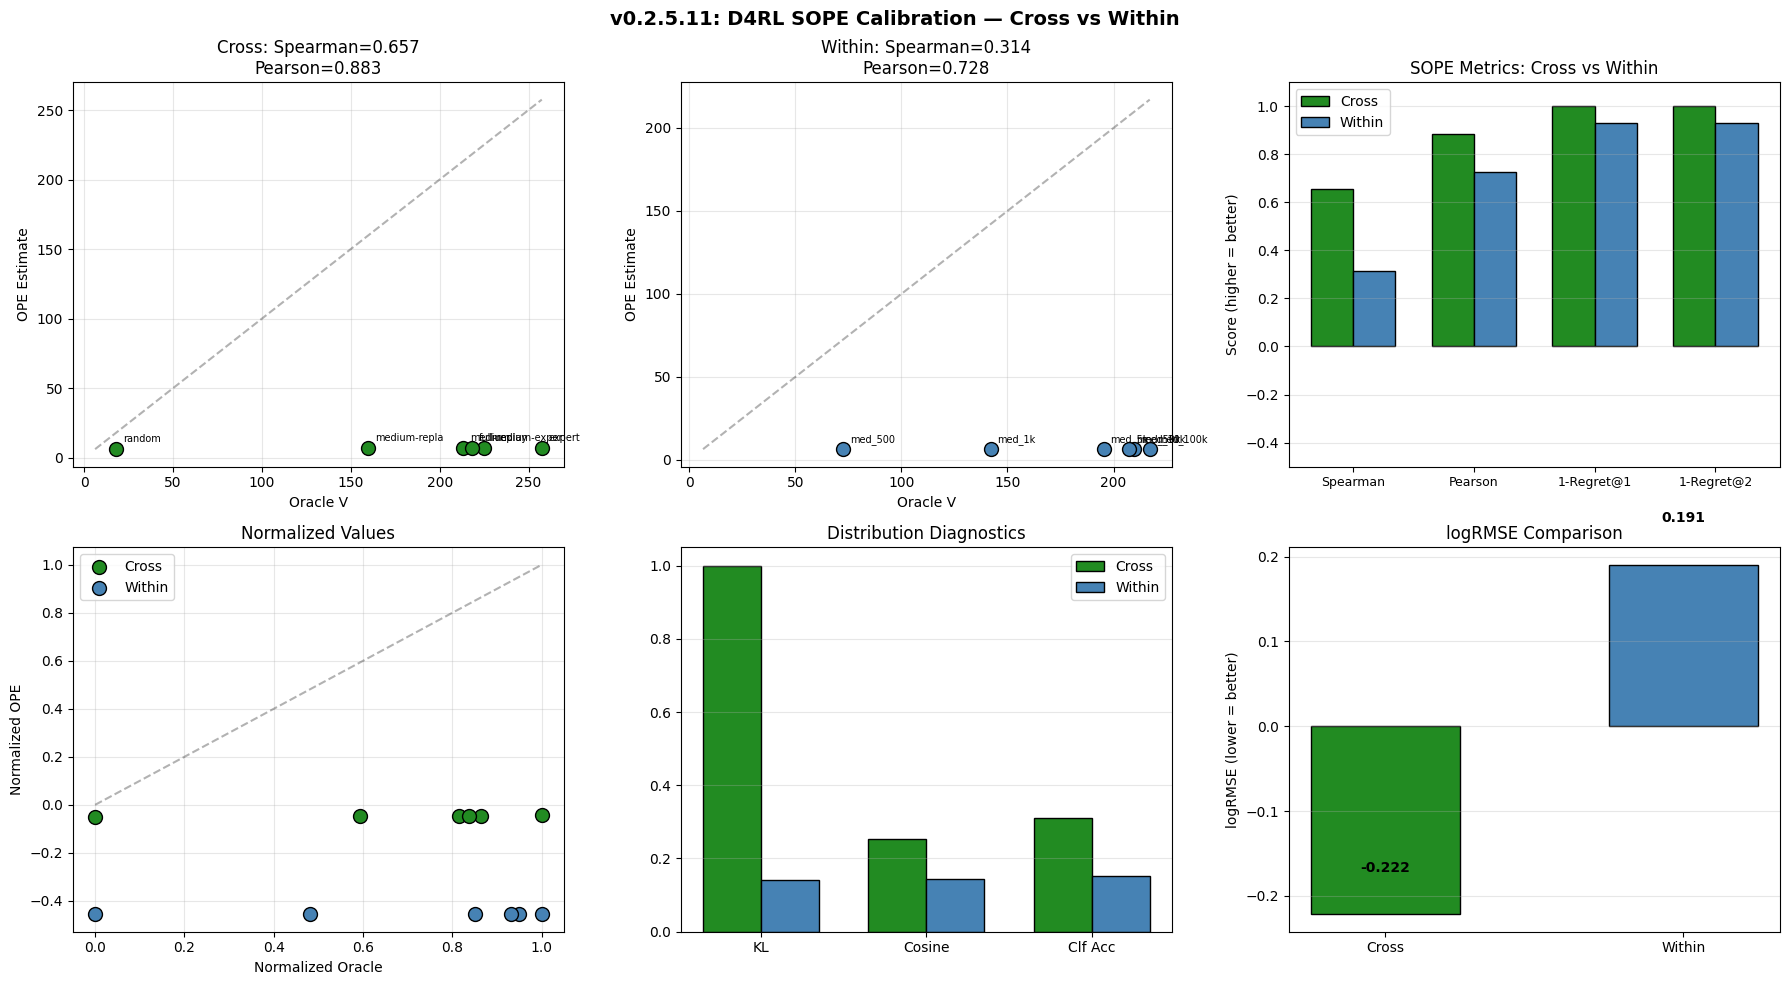

In [12]:
# ── Step 8: Visualizations ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: Cross-dataset Oracle vs OPE scatter
ax = axes[0, 0]
ax.scatter(cross_metrics["oracle"], cross_metrics["ope_est"], s=100, c="forestgreen", edgecolor="black", zorder=5)
for i, n in enumerate(cross_names):
    ax.annotate(n[:12], (cross_metrics["oracle"][i], cross_metrics["ope_est"][i]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
# Perfect line
lo = min(cross_metrics["oracle"].min(), cross_metrics["ope_est"].min())
hi = max(cross_metrics["oracle"].max(), cross_metrics["ope_est"].max())
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3)
ax.set_xlabel("Oracle V"); ax.set_ylabel("OPE Estimate")
ax.set_title(f"Cross: Spearman={cross_metrics['spearman']:.3f}\nPearson={cross_metrics['pearson']:.3f}")
ax.grid(True, alpha=0.3)

# Panel 2: Within-dataset Oracle vs OPE scatter
ax = axes[0, 1]
ax.scatter(within_metrics["oracle"], within_metrics["ope_est"], s=100, c="steelblue", edgecolor="black", zorder=5)
for i, n in enumerate(within_names):
    ax.annotate(n, (within_metrics["oracle"][i], within_metrics["ope_est"][i]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
lo = min(within_metrics["oracle"].min(), within_metrics["ope_est"].min())
hi = max(within_metrics["oracle"].max(), within_metrics["ope_est"].max())
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3)
ax.set_xlabel("Oracle V"); ax.set_ylabel("OPE Estimate")
ax.set_title(f"Within: Spearman={within_metrics['spearman']:.3f}\nPearson={within_metrics['pearson']:.3f}")
ax.grid(True, alpha=0.3)

# Panel 3: Metrics comparison bar chart
ax = axes[0, 2]
metrics_names = ["Spearman", "Pearson", "1-Regret@1", "1-Regret@2"]
cross_vals = [cross_metrics["spearman"], cross_metrics["pearson"],
              1-cross_metrics["regret_1"], 1-cross_metrics["regret_2"]]
within_vals = [within_metrics["spearman"], within_metrics["pearson"],
               1-within_metrics["regret_1"], 1-within_metrics["regret_2"]]
x = np.arange(len(metrics_names))
w = 0.35
ax.bar(x - w/2, cross_vals, w, color="forestgreen", edgecolor="black", label="Cross")
ax.bar(x + w/2, within_vals, w, color="steelblue", edgecolor="black", label="Within")
ax.set_xticks(x); ax.set_xticklabels(metrics_names, fontsize=9)
ax.set_ylabel("Score (higher = better)")
ax.set_title("SOPE Metrics: Cross vs Within")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim([-0.5, 1.1])

# Panel 4: Normalized Oracle vs OPE (both sets together)
ax = axes[1, 0]
ax.scatter(cross_metrics["norm_oracle"], cross_metrics["norm_ope"],
           s=100, c="forestgreen", edgecolor="black", label="Cross", zorder=5)
ax.scatter(within_metrics["norm_oracle"], within_metrics["norm_ope"],
           s=100, c="steelblue", edgecolor="black", label="Within", zorder=5)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Normalized Oracle"); ax.set_ylabel("Normalized OPE")
ax.set_title("Normalized Values"); ax.legend(); ax.grid(True, alpha=0.3)

# Panel 5: Custom diagnostics comparison
ax = axes[1, 1]
diag_names = ["KL", "Cosine", "Clf Acc"]
cross_d = [cross_diag["mean_kl"] / max(cross_diag["mean_kl"], within_diag["mean_kl"]),
           cross_diag["mean_cos"], cross_diag["classifier_acc"]]
within_d = [within_diag["mean_kl"] / max(cross_diag["mean_kl"], within_diag["mean_kl"]),
            within_diag["mean_cos"], within_diag["classifier_acc"]]
x = np.arange(len(diag_names))
ax.bar(x - w/2, cross_d, w, color="forestgreen", edgecolor="black", label="Cross")
ax.bar(x + w/2, within_d, w, color="steelblue", edgecolor="black", label="Within")
ax.set_xticks(x); ax.set_xticklabels(diag_names)
ax.set_title("Distribution Diagnostics"); ax.legend(); ax.grid(True, alpha=0.3, axis="y")

# Panel 6: logRMSE comparison
ax = axes[1, 2]
ax.bar(["Cross", "Within"], [cross_metrics["log_rmse"], within_metrics["log_rmse"]],
       color=["forestgreen", "steelblue"], edgecolor="black", width=0.5)
for i, v in enumerate([cross_metrics["log_rmse"], within_metrics["log_rmse"]]):
    ax.text(i, v + 0.05, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylabel("logRMSE (lower = better)")
ax.set_title("logRMSE Comparison"); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("v0.2.5.11: D4RL SOPE Calibration — Cross vs Within", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

v0.2.5.11: D4RL SOPE CALIBRATION — GRAND SUMMARY

SOPE OPE Metrics             Cross (6)   Within (6)
──────────────────────────────────────────────────
Spearman rho                   +0.6571      +0.3143
Pearson r                      +0.8829      +0.7281
Regret@1                        0.0000       0.0685
Regret@2                        0.0000       0.0685
logRMSE                        -0.2217       0.1905
──────────────────────────────────────────────────

Distribution Diagnostics     Cross (6)   Within (6)    SAC ref
────────────────────────────────────────────────────────────
Mean KL                         126.30        17.80          —
Mean Cosine                     0.2520       0.1452     0.4737
Mean W1                         0.1452       0.0794          —
Classifier Acc                  31.2%       15.3%          —
  (chance)                      16.7%       16.7%          —
|grad|/|act| ratio                23.5          6.5      572.7
GD convergence                 +288.7

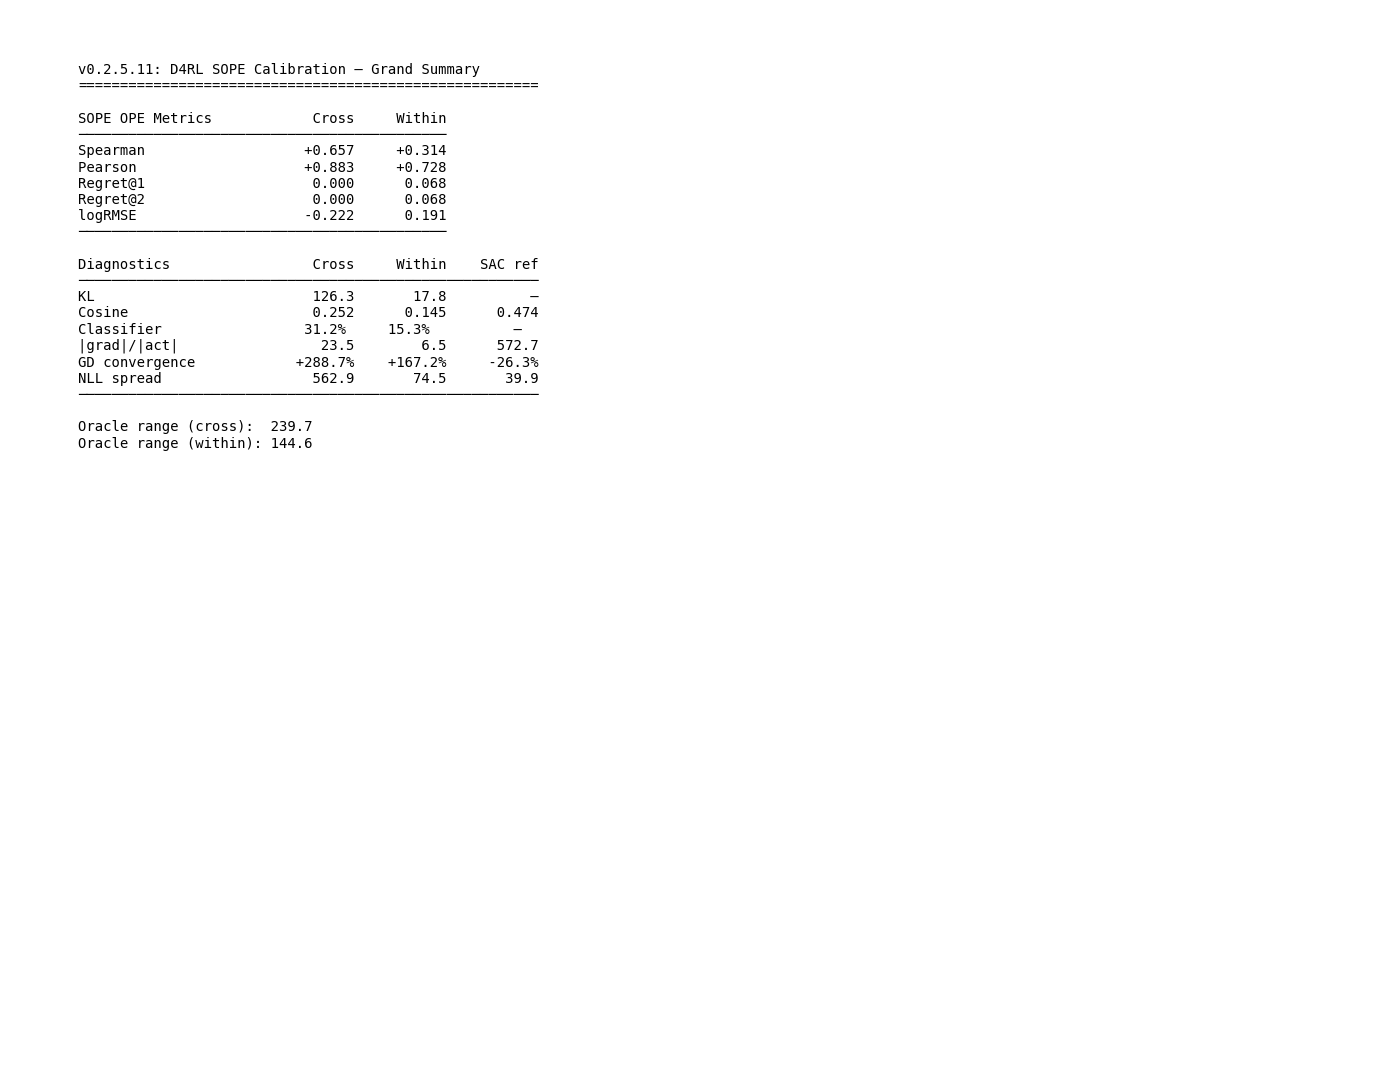

In [13]:
# ── Grand Summary ──
print(f"{'='*80}")
print(f"v0.2.5.11: D4RL SOPE CALIBRATION — GRAND SUMMARY")
print(f"{'='*80}")

print(f"\n{'SOPE OPE Metrics':<25} {'Cross (6)':>12} {'Within (6)':>12}")
print(f"{'─'*50}")
print(f"{'Spearman rho':<25} {cross_metrics['spearman']:>+12.4f} {within_metrics['spearman']:>+12.4f}")
print(f"{'Pearson r':<25} {cross_metrics['pearson']:>+12.4f} {within_metrics['pearson']:>+12.4f}")
print(f"{'Regret@1':<25} {cross_metrics['regret_1']:>12.4f} {within_metrics['regret_1']:>12.4f}")
print(f"{'Regret@2':<25} {cross_metrics['regret_2']:>12.4f} {within_metrics['regret_2']:>12.4f}")
print(f"{'logRMSE':<25} {cross_metrics['log_rmse']:>12.4f} {within_metrics['log_rmse']:>12.4f}")
print(f"{'─'*50}")

print(f"\n{'Distribution Diagnostics':<25} {'Cross (6)':>12} {'Within (6)':>12} {'SAC ref':>10}")
print(f"{'─'*60}")
print(f"{'Mean KL':<25} {cross_diag['mean_kl']:>12.2f} {within_diag['mean_kl']:>12.2f} {'—':>10}")
print(f"{'Mean Cosine':<25} {cross_diag['mean_cos']:>12.4f} {within_diag['mean_cos']:>12.4f} {'0.4737':>10}")
print(f"{'Mean W1':<25} {cross_diag['mean_w1']:>12.4f} {within_diag['mean_w1']:>12.4f} {'—':>10}")
print(f"{'Classifier Acc':<25} {cross_diag['classifier_acc']:>11.1%} {within_diag['classifier_acc']:>11.1%} {'—':>10}")
print(f"{'  (chance)':<25} {cross_diag['chance']:>11.1%} {within_diag['chance']:>11.1%} {'—':>10}")
print(f"{'|grad|/|act| ratio':<25} {cross_extra['mean_ratio']:>12.1f} {within_extra['mean_ratio']:>12.1f} {'572.7':>10}")
print(f"{'GD convergence':<25} {cross_extra['mean_gd']:>+11.1f}% {within_extra['mean_gd']:>+11.1f}% {'-26.3%':>10}")
print(f"{'NLL spread':<25} {cross_extra['nll_spread']:>12.1f} {within_extra['nll_spread']:>12.1f} {'39.9':>10}")
print(f"{'─'*60}")

print(f"\nOracle value ranges:")
cross_oracle = [oracle_values[n]["mean"] for n in cross_names]
within_oracle = [oracle_values[n]["mean"] for n in within_names]
print(f"  Cross:  [{min(cross_oracle):.1f}, {max(cross_oracle):.1f}] (range={max(cross_oracle)-min(cross_oracle):.1f})")
print(f"  Within: [{min(within_oracle):.1f}, {max(within_oracle):.1f}] (range={max(within_oracle)-min(within_oracle):.1f})")

# Verdict
print(f"\n{'='*80}")
print("VERDICT:")
if cross_metrics["spearman"] > 0.5 and within_metrics["spearman"] < 0.3:
    print("  CONFIRMED: Guidance works for cross-dataset but NOT within-dataset.")
    print("  This matches our Lift finding — guidance requires genuinely different")
    print("  behavior distributions, not just different data scales.")
elif cross_metrics["spearman"] > 0.5 and within_metrics["spearman"] > 0.5:
    print("  SURPRISING: Guidance works for BOTH settings. Our Lift problem may")
    print("  be implementation-specific, not fundamental.")
elif cross_metrics["spearman"] < 0.3:
    print("  BC_Gaussian scorers don't work well even cross-dataset on D4RL.")
    print("  The issue may be BC_Gaussian approximation, not diversity.")
else:
    print(f"  MIXED: Cross Spearman={cross_metrics['spearman']:.3f}, "
          f"Within={within_metrics['spearman']:.3f}")
    print("  Need further analysis.")
print(f"{'='*80}")

# Summary figure
fig, ax = plt.subplots(1, 1, figsize=(14, 11))
ax.axis("off")
lines = [
    "v0.2.5.11: D4RL SOPE Calibration — Grand Summary", "=" * 55, "",
    f"{'SOPE OPE Metrics':<22} {'Cross':>10} {'Within':>10}",
    "─" * 44,
    f"{'Spearman':<22} {cross_metrics['spearman']:>+10.3f} {within_metrics['spearman']:>+10.3f}",
    f"{'Pearson':<22} {cross_metrics['pearson']:>+10.3f} {within_metrics['pearson']:>+10.3f}",
    f"{'Regret@1':<22} {cross_metrics['regret_1']:>10.3f} {within_metrics['regret_1']:>10.3f}",
    f"{'Regret@2':<22} {cross_metrics['regret_2']:>10.3f} {within_metrics['regret_2']:>10.3f}",
    f"{'logRMSE':<22} {cross_metrics['log_rmse']:>10.3f} {within_metrics['log_rmse']:>10.3f}",
    "─" * 44, "",
    f"{'Diagnostics':<22} {'Cross':>10} {'Within':>10} {'SAC ref':>10}",
    "─" * 55,
    f"{'KL':<22} {cross_diag['mean_kl']:>10.1f} {within_diag['mean_kl']:>10.1f} {'—':>10}",
    f"{'Cosine':<22} {cross_diag['mean_cos']:>10.3f} {within_diag['mean_cos']:>10.3f} {'0.474':>10}",
    f"{'Classifier':<22} {cross_diag['classifier_acc']:>9.1%} {within_diag['classifier_acc']:>9.1%} {'—':>10}",
    f"{'|grad|/|act|':<22} {cross_extra['mean_ratio']:>10.1f} {within_extra['mean_ratio']:>10.1f} {'572.7':>10}",
    f"{'GD convergence':<22} {cross_extra['mean_gd']:>+9.1f}% {within_extra['mean_gd']:>+9.1f}% {'-26.3%':>10}",
    f"{'NLL spread':<22} {cross_extra['nll_spread']:>10.1f} {within_extra['nll_spread']:>10.1f} {'39.9':>10}",
    "─" * 55, "",
    f"Oracle range (cross):  {max(cross_oracle)-min(cross_oracle):.1f}",
    f"Oracle range (within): {max(within_oracle)-min(within_oracle):.1f}",
]
ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()